# IT Support Ticket Priority Classifier
### Machine Learning Project | NLP | Scikit-Learn | Streamlit

---

## Problem Statement

IT support teams receive hundreds of tickets every day. Manually deciding whether a ticket is **High**, **Medium**, or **Low** priority is slow and inconsistent.

**Goal:** Build an ML model that reads a ticket description and automatically predicts its priority.

**Approach:** We train a quick **Naive Bayes baseline** for reference, then focus on two stronger, tuned models for the final deployed system:
- **TF-IDF + Logistic Regression** (GridSearchCV tuned)
- **TF-IDF + Linear SVM** (GridSearchCV tuned)

This mirrors how real-world text classification projects are built — establish a baseline, then beat it with tuned models.

---

## Tools Used

| Tool | Purpose |
|------|---------|
| `pandas` / `numpy` | Data loading and manipulation |
| `matplotlib` / `seaborn` | Visualizations |
| `nltk` | Text preprocessing (stopwords, lemmatization) |
| `scikit-learn` | TF-IDF, models, GridSearchCV, evaluation |
| `joblib` | Save and load trained model |
| `streamlit` | Web app deployment |

---
## Part 1 — Imports

In [1]:
# ── Standard libraries ────────────────────────────────────────────────────────
import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical visualizations
import re                        # Regular expressions for text cleaning
import os                        # File and folder operations
import warnings
warnings.filterwarnings('ignore')

# ── NLTK — Natural Language Toolkit ──────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)   # Common words to remove
nltk.download('wordnet',   quiet=True)   # For lemmatization
nltk.download('omw-1.4',   quiet=True)   # WordNet support
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer  # Reduces words to base form

# ── Scikit-Learn: Feature Extraction ─────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-Learn: Model Selection ────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# ── Scikit-Learn: Models ──────────────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB     # Used only as a baseline (Part 6)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# ── Scikit-Learn: Evaluation Metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ── Model Persistence ─────────────────────────────────────────────────────────
import joblib

# ── Create required folders ───────────────────────────────────────────────────
os.makedirs('../images', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
COLORS = {'High': '#E24B4A', 'Medium': '#EF9F27', 'Low': '#639922'}

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Part 2 — EDA (Exploratory Data Analysis)

Loading the dataset and understanding its structure, shape, and class balance.

In [2]:
# Load dataset (you already have your 600-row tickets_dataset.csv in data/)
df = pd.read_csv('../data/tickets_dataset.csv')

print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns      : {df.columns.tolist()}')
df.head()

Dataset Shape: 600 rows x 4 columns
Columns      : ['ticket_id', 'description', 'category', 'priority']


,ticket_id,description,category,priority
0,1,My laptop screen is completely black and I can...,Hardware,High
1,2,I forgot my email password and cannot login,Account,Low
2,3,The entire office network is down and nobody c...,Network,High
3,4,My mouse is not working properly sometimes it ...,Hardware,Low
4,5,Server is down and all customer data is inacce...,Server,High


In [3]:
print('Dataset Info:')
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

print(f'\nDuplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df.shape}')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    600 non-null    int64 
 1   description  600 non-null    object
 2   category     600 non-null    object
 3   priority     600 non-null    object
dtypes: int64(1), object(3)
memory usage: 18.9+ KB

Missing values per column:
ticket_id      0
description    0
category       0
priority       0
dtype: int64

Duplicate rows: 0
Shape after removing duplicates: (600, 4)


In [4]:
print('Priority Distribution:')
print(df['priority'].value_counts())
print(f'\nPriority % breakdown:')
print(df['priority'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print(f'\nUnique Categories ({df["category"].nunique()}): {sorted(df["category"].unique())}')

# Add ticket length feature (word count) — useful for EDA
df['ticket_length'] = df['description'].apply(lambda x: len(str(x).split()))
print('\nTicket length stats by priority:')
print(df.groupby('priority')['ticket_length'].describe().round(2))

Priority Distribution:
priority
Low       219
High      201
Medium    180
Name: count, dtype: int64

Priority % breakdown:
priority
Low       36.5%
High      33.5%
Medium    30.0%
Name: proportion, dtype: object

Unique Categories (16): ['Access', 'Account', 'Backup', 'Billing', 'Data', 'Database', 'Documentation', 'Email', 'General Inquiry', 'Hardware', 'Infrastructure', 'Network', 'Performance', 'Security', 'Server', 'Software']

Ticket length stats by priority:
          count  mean   std  min  25%  50%  75%   max
priority                                             
High      201.0  5.86  1.18  3.0  5.0  6.0  6.0  12.0
Low       219.0  5.85  1.20  4.0  5.0  6.0  6.0  11.0
Medium    180.0  5.96  0.88  4.0  5.0  6.0  6.0   9.0


---
## Part 3 — Visualization

Charts that reveal patterns in the data before modeling.

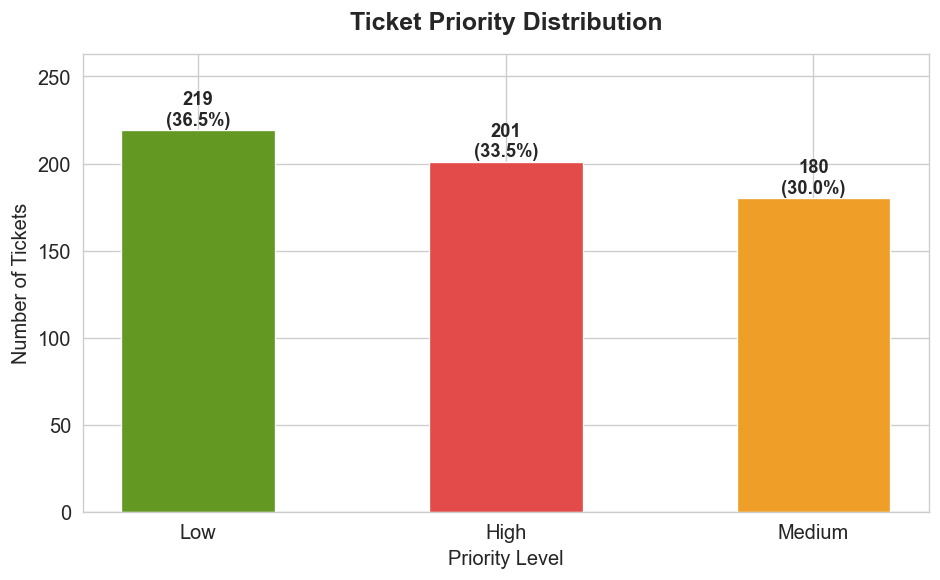

In [5]:
# ── Chart 1: Priority Distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
priority_counts = df['priority'].value_counts()
bars = ax.bar(priority_counts.index, priority_counts.values,
              color=[COLORS[p] for p in priority_counts.index],
              edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Ticket Priority Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Priority Level'); ax.set_ylabel('Number of Tickets')
ax.set_ylim(0, priority_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('../images/01_priority_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

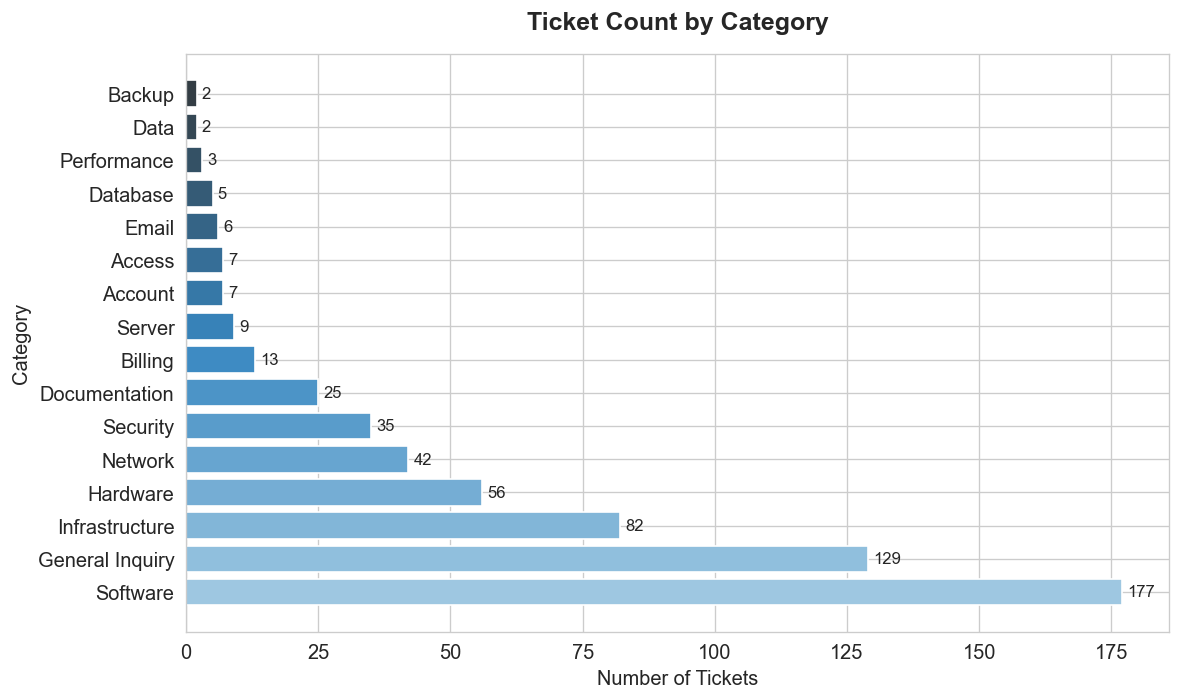

In [6]:
# ── Chart 2: Category Distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cat_counts = df['category'].value_counts()
palette = sns.color_palette('Blues_d', len(cat_counts))
bars = ax.barh(cat_counts.index, cat_counts.values, color=palette, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)
ax.set_title('Ticket Count by Category', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tickets'); ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('../images/02_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

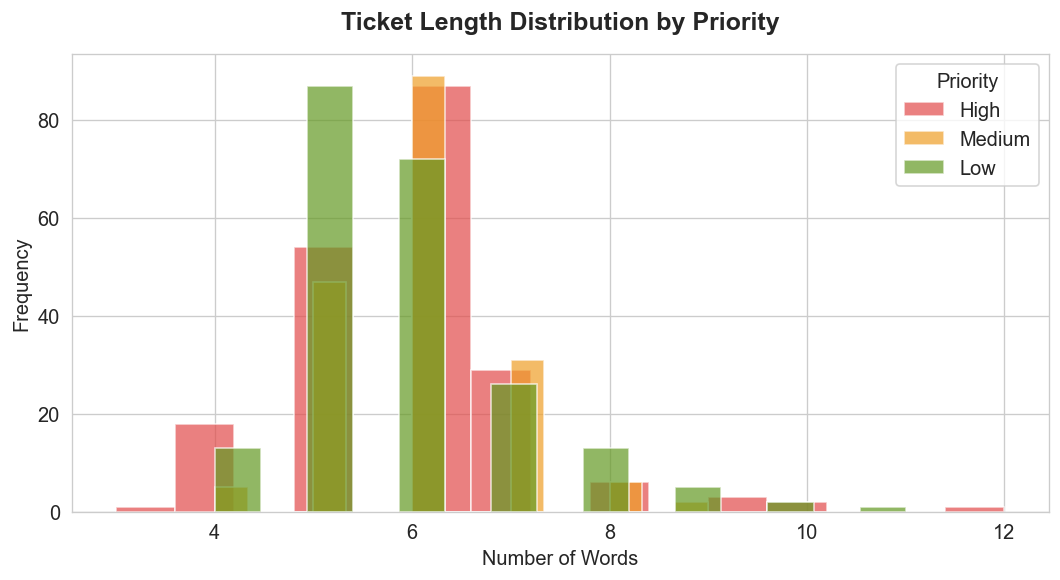

In [7]:
# ── Chart 3: Ticket Length Distribution by Priority ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for priority, color in COLORS.items():
    subset = df[df['priority'] == priority]['ticket_length']
    ax.hist(subset, bins=15, alpha=0.7, label=priority, color=color, edgecolor='white')
ax.set_title('Ticket Length Distribution by Priority', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Words'); ax.set_ylabel('Frequency')
ax.legend(title='Priority')
plt.tight_layout()
plt.savefig('../images/03_ticket_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

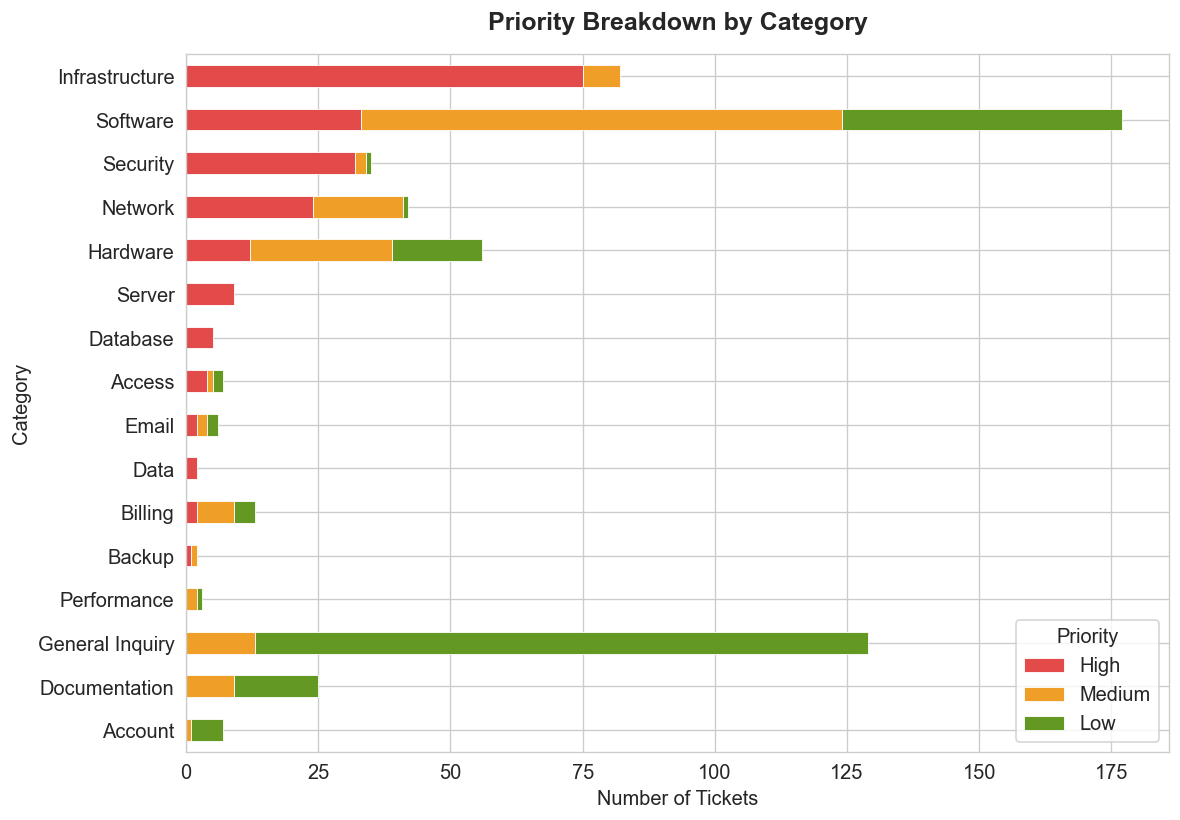

All EDA charts saved in images/ folder!


In [8]:
# ── Chart 4: Category vs Priority (Stacked Bar) ───────────────────────────────
cat_priority = df.groupby(['category', 'priority']).size().unstack(fill_value=0)
for col in ['High', 'Medium', 'Low']:
    if col not in cat_priority.columns:
        cat_priority[col] = 0
cat_priority = cat_priority[['High', 'Medium', 'Low']].sort_values('High', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
cat_priority.plot(kind='barh', stacked=True,
                  color=[COLORS['High'], COLORS['Medium'], COLORS['Low']],
                  ax=ax, edgecolor='white', linewidth=0.5)
ax.set_title('Priority Breakdown by Category', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tickets'); ax.set_ylabel('Category')
ax.legend(title='Priority', loc='lower right')
plt.tight_layout()
plt.savefig('../images/04_category_vs_priority.png', dpi=150, bbox_inches='tight')
plt.show()
print('All EDA charts saved in images/ folder!')

---
## Part 4 — Cleaning (Text Preprocessing)

**Pipeline:** lowercase → remove URLs → remove punctuation/numbers → remove extra spaces → remove stopwords → lemmatize.

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Full text preprocessing pipeline.
    Input : raw ticket description (string)
    Output: cleaned, lemmatized string
    """
    text = str(text).lower()                          # Step 1: lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # Step 2: remove URLs
    text = re.sub(r'[^a-z\s]', '', text)               # Step 3: remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()            # Step 4: remove extra spaces
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]  # Step 5: remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]    # Step 6: lemmatize
    return ' '.join(words)

df['cleaned_description'] = df['description'].apply(clean_text)

print('Text preprocessing complete!')
print('\nExamples — BEFORE vs AFTER:')
print('=' * 70)
for i in [0, 50, 150]:
    print(f'BEFORE: {df.iloc[i]["description"]}')
    print(f'AFTER : {df.iloc[i]["cleaned_description"]}')
    print('-' * 70)

Text preprocessing complete!

Examples — BEFORE vs AFTER:
BEFORE: My laptop screen is completely black and I cannot turn it on
AFTER : laptop screen completely black cannot turn
----------------------------------------------------------------------
BEFORE: My speakers have no sound
AFTER : speaker sound
----------------------------------------------------------------------
BEFORE: VPN service completely unavailable for remote workers
AFTER : vpn service completely unavailable remote worker
----------------------------------------------------------------------


---
## Part 5 — TF-IDF (Improved)

**Parameters explained:**
- `max_features=2000` → keep top 2000 most important words
- `ngram_range=(1,2)` → use single words AND word pairs (bigrams)
- `min_df=2` → ignore words that appear in fewer than 2 tickets
- `max_df=0.95` → ignore words that appear in more than 95% of tickets
- `sublinear_tf=True` → apply log scaling to term frequency

In [10]:
X = df['cleaned_description']
y = df['priority']

# 80/20 split with stratify to keep class ratio balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {len(X_train)} samples')
print(f'Testing set  : {len(X_test)} samples')

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

Training set : 480 samples
Testing set  : 120 samples

TF-IDF matrix shape (train): (480, 475)
TF-IDF matrix shape (test) : (120, 475)


---
### Quick Baseline — Naive Bayes

Before tuning Logistic Regression and SVM, we train a simple Naive Bayes model. This gives us a **baseline score** — any model we tune afterward should beat this.

In [11]:
# Naive Bayes — baseline only, NOT used in final deployment
nb_baseline = MultinomialNB()
nb_baseline.fit(X_train_tfidf, y_train)
nb_pred = nb_baseline.predict(X_test_tfidf)
nb_acc  = accuracy_score(y_test, nb_pred)

print(f'Naive Bayes Baseline Accuracy: {nb_acc*100:.2f}%')
print('(This is our baseline — Logistic Regression and SVM should beat this)')

Naive Bayes Baseline Accuracy: 81.67%
(This is our baseline — Logistic Regression and SVM should beat this)


---
## Part 6 — Logistic Regression (GridSearchCV)

GridSearchCV automatically tries all hyperparameter combinations using cross-validation and picks the best one.

In [12]:
lr_params = {
    'C'            : [0.1, 1.0, 10.0],    # Regularization strength
    'solver'       : ['lbfgs', 'saga'],   # Optimization algorithm
    'class_weight' : [None, 'balanced'],  # Handle class imbalance
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)

print('Running GridSearchCV for Logistic Regression...')
lr_grid.fit(X_train_tfidf, y_train)

print(f'\nBest Parameters : {lr_grid.best_params_}')
print(f'Best CV Score   : {lr_grid.best_score_*100:.2f}%')

lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test_tfidf)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec  = recall_score(y_test, lr_pred, average='weighted')
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

print(f'\nLogistic Regression Results:')
print(f'  Accuracy  : {lr_acc*100:.2f}%')
print(f'  Precision : {lr_prec*100:.2f}%')
print(f'  Recall    : {lr_rec*100:.2f}%')
print(f'  F1 Score  : {lr_f1*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, lr_pred, digits=4))

Running GridSearchCV for Logistic Regression...

Best Parameters : {'C': 10.0, 'class_weight': 'balanced', 'solver': 'saga'}
Best CV Score   : 85.58%

Logistic Regression Results:
  Accuracy  : 82.50%
  Precision : 82.47%
  Recall    : 82.50%
  F1 Score  : 82.38%

Classification Report:
              precision    recall  f1-score   support

        High     0.9487    0.9250    0.9367        40
         Low     0.7917    0.8636    0.8261        44
      Medium     0.7273    0.6667    0.6957        36

    accuracy                         0.8250       120
   macro avg     0.8226    0.8184    0.8195       120
weighted avg     0.8247    0.8250    0.8238       120



---
## Part 7 — Linear SVM (GridSearchCV)

LinearSVC finds the optimal boundary between classes and is fast + accurate for TF-IDF text features.

In [13]:
svm_params = {
    'C'            : [0.1, 1.0, 10.0],
    'loss'         : ['hinge', 'squared_hinge'],
    'class_weight' : [None, 'balanced'],
}

svm_grid = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=42),
    svm_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)

print('Running GridSearchCV for Linear SVM...')
svm_grid.fit(X_train_tfidf, y_train)

print(f'\nBest Parameters : {svm_grid.best_params_}')
print(f'Best CV Score   : {svm_grid.best_score_*100:.2f}%')

svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test_tfidf)

svm_acc  = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred, average='weighted')
svm_rec  = recall_score(y_test, svm_pred, average='weighted')
svm_f1   = f1_score(y_test, svm_pred, average='weighted')

print(f'\nLinear SVM Results:')
print(f'  Accuracy  : {svm_acc*100:.2f}%')
print(f'  Precision : {svm_prec*100:.2f}%')
print(f'  Recall    : {svm_rec*100:.2f}%')
print(f'  F1 Score  : {svm_f1*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, svm_pred, digits=4))

Running GridSearchCV for Linear SVM...

Best Parameters : {'C': 1.0, 'class_weight': None, 'loss': 'squared_hinge'}
Best CV Score   : 84.69%

Linear SVM Results:
  Accuracy  : 80.83%
  Precision : 80.60%
  Recall    : 80.83%
  F1 Score  : 80.32%

Classification Report:
              precision    recall  f1-score   support

        High     0.9250    0.9250    0.9250        40
         Low     0.7647    0.8864    0.8211        44
      Medium     0.7241    0.5833    0.6462        36

    accuracy                         0.8083       120
   macro avg     0.8046    0.7982    0.7974       120
weighted avg     0.8060    0.8083    0.8032       120



---
## Part 8 — Comparison Table

Side-by-side comparison of our two tuned models (Naive Bayes shown only as reference baseline).

In [14]:
comparison_df = pd.DataFrame({
    'Model'     : ['Naive Bayes (baseline)', 'Logistic Regression', 'Linear SVM'],
    'Accuracy'  : [round(nb_acc*100, 2), round(lr_acc*100, 2), round(svm_acc*100, 2)],
    'Precision' : [None, round(lr_prec*100, 2), round(svm_prec*100, 2)],
    'Recall'    : [None, round(lr_rec*100, 2), round(svm_rec*100, 2)],
    'F1'        : [None, round(lr_f1*100, 2), round(svm_f1*100, 2)],
})

print('Model Comparison Table:')
print(comparison_df.to_string(index=False))
comparison_df

Model Comparison Table:
                 Model  Accuracy  Precision  Recall    F1
Naive Bayes (baseline)     81.67        NaN     NaN   NaN
   Logistic Regression     82.50      82.47   82.50 82.38
            Linear SVM     80.83      80.60   80.83 80.32


,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes (baseline),81.67,NaN,NaN,NaN
1,Logistic Regression,82.50,82.47,82.50,82.38
2,Linear SVM,80.83,80.60,80.83,80.32


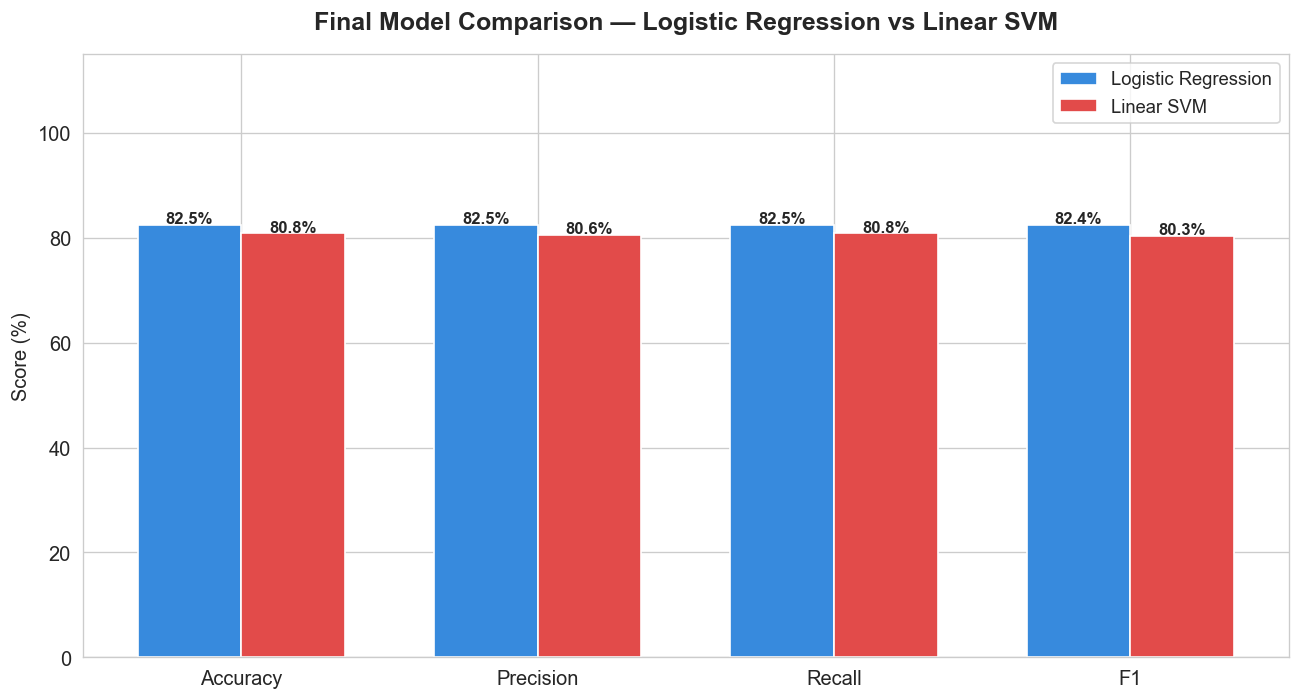

In [15]:
# Bar chart — Logistic Regression vs Linear SVM (the two final candidates)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x       = np.arange(len(metrics))
width   = 0.35

lr_vals  = [lr_acc*100, lr_prec*100, lr_rec*100, lr_f1*100]
svm_vals = [svm_acc*100, svm_prec*100, svm_rec*100, svm_f1*100]

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='#378ADD', edgecolor='white')
bars2 = ax.bar(x + width/2, svm_vals, width, label='Linear SVM', color='#E24B4A', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Final Model Comparison — Logistic Regression vs Linear SVM', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Score (%)')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../images/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 9 — Cross Validation

5-fold cross-validation gives a more reliable estimate than a single train/test split.

5-Fold Cross-Validation Results:
Logistic Regression : Mean F1 = 82.41%  (Std = 14.54%)
Linear SVM           : Mean F1 = 82.73%  (Std = 13.69%)

Lower Std Dev = more consistent model = less overfitting risk


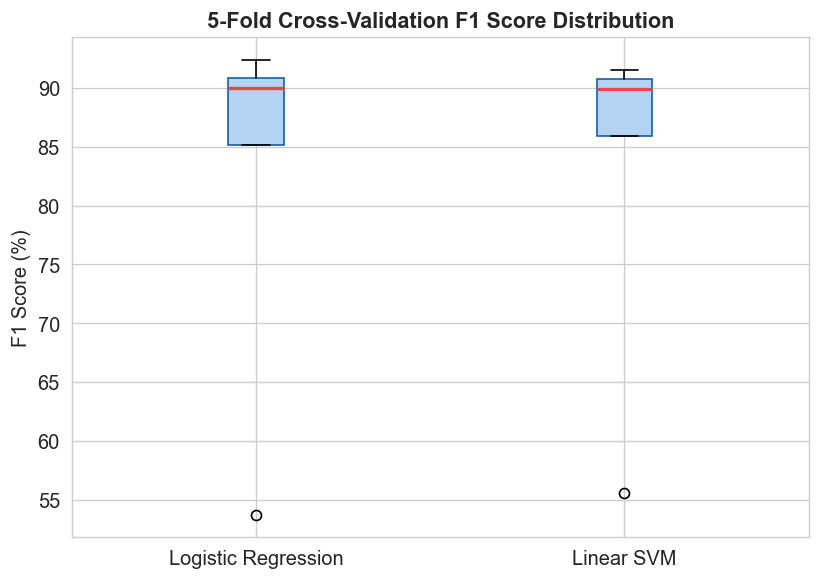

In [16]:
X_all = tfidf.fit_transform(df['cleaned_description'])
y_all = df['priority']

lr_cv  = cross_val_score(lr_best,  X_all, y_all, cv=5, scoring='f1_weighted')
svm_cv = cross_val_score(svm_best, X_all, y_all, cv=5, scoring='f1_weighted')

print('5-Fold Cross-Validation Results:')
print('=' * 55)
print(f'Logistic Regression : Mean F1 = {lr_cv.mean()*100:.2f}%  (Std = {lr_cv.std()*100:.2f}%)')
print(f'Linear SVM           : Mean F1 = {svm_cv.mean()*100:.2f}%  (Std = {svm_cv.std()*100:.2f}%)')
print('\nLower Std Dev = more consistent model = less overfitting risk')

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([lr_cv*100, svm_cv*100], labels=['Logistic Regression', 'Linear SVM'],
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#E24B4A', linewidth=2))
ax.set_title('5-Fold Cross-Validation F1 Score Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score (%)')
plt.tight_layout()
plt.savefig('../images/06_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 10 — Confusion Matrix

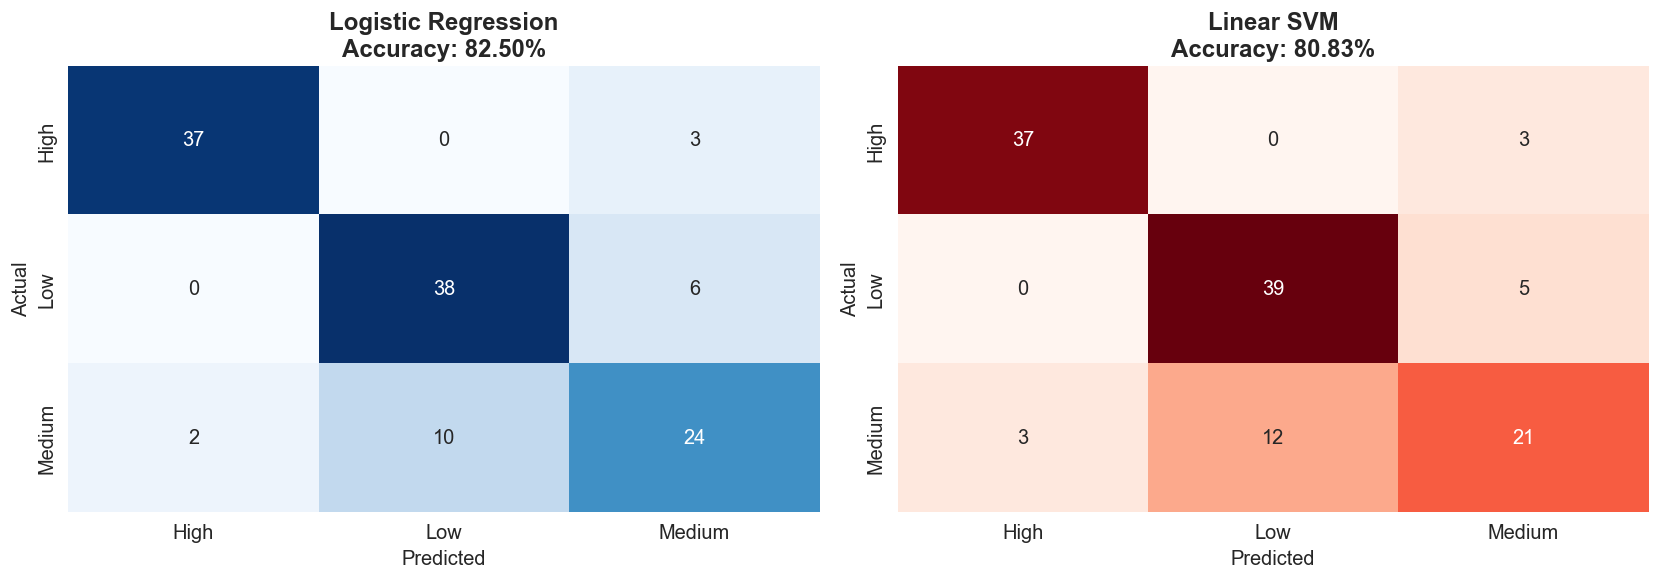

In [17]:
labels = ['High', 'Low', 'Medium']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_svm = confusion_matrix(y_test, svm_pred, labels=labels)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False)
axes[1].set_title(f'Linear SVM\nAccuracy: {svm_acc*100:.2f}%', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 11 — Save Best Model

Automatically select the better of the two tuned models (Logistic Regression vs Linear SVM) based on F1 score.

In [18]:
if svm_f1 >= lr_f1:
    best_model      = svm_best
    best_model_name = 'Linear SVM'
    best_f1         = svm_f1
else:
    best_model      = lr_best
    best_model_name = 'Logistic Regression'
    best_f1         = lr_f1

print(f'Best Model Selected : {best_model_name}')
print(f'F1 Score            : {best_f1*100:.2f}%')

# Retrain best model on the FULL dataset before saving (more data = better final model)
X_all_tfidf = tfidf.fit_transform(df['cleaned_description'])
best_model.fit(X_all_tfidf, y_all)

joblib.dump(best_model, '../models/model.pkl')
joblib.dump(tfidf,      '../models/vectorizer.pkl')

print(f'\nSaved: models/model.pkl')
print(f'Saved: models/vectorizer.pkl')

Best Model Selected : Logistic Regression
F1 Score            : 82.38%

Saved: models/model.pkl
Saved: models/vectorizer.pkl


---
## Part 12 — Prediction Function

Reusable function that loads the saved model and predicts priority for any new ticket text.

In [19]:
def predict_priority(ticket_text):
    """
    Predict the priority of a new IT support ticket.

    Parameters
    ----------
    ticket_text : str — raw ticket description

    Returns
    -------
    str — predicted priority: 'High', 'Medium', or 'Low'
    """
    model_      = joblib.load('../models/model.pkl')
    vectorizer_ = joblib.load('../models/vectorizer.pkl')

    cleaned  = clean_text(ticket_text)
    features = vectorizer_.transform([cleaned])
    return model_.predict(features)[0]


test_tickets = [
    'Server crashed and all customer data is lost',
    'Entire company network is completely down',
    'Ransomware detected on all company servers',
    'My printer is not working since this morning',
    'VPN keeps disconnecting during work calls',
    'I need Microsoft Word installed on my laptop',
    'I forgot my email password please reset it',
    'Please install Adobe Reader on my computer',
]

emoji_map = {'High': '\U0001F534', 'Medium': '\U0001F7E1', 'Low': '\U0001F7E2'}

print('PREDICTION RESULTS')
print('=' * 70)
for ticket in test_tickets:
    priority = predict_priority(ticket)
    print(f'{emoji_map[priority]} [{priority:6}]  {ticket}')
print('=' * 70)

PREDICTION RESULTS
🔴 [High  ]  Server crashed and all customer data is lost
🔴 [High  ]  Entire company network is completely down
🔴 [High  ]  Ransomware detected on all company servers
🟡 [Medium]  My printer is not working since this morning
🟡 [Medium]  VPN keeps disconnecting during work calls
🟢 [Low   ]  I need Microsoft Word installed on my laptop
🟡 [Medium]  I forgot my email password please reset it
🟡 [Medium]  Please install Adobe Reader on my computer


---
## Conclusion

| Component | Details |
|-----------|----------|
| **Dataset** | 600 labeled IT support tickets (High / Medium / Low) |
| **Preprocessing** | Lowercase, URL removal, punctuation removal, stopwords, lemmatization |
| **Vectorization** | TF-IDF (2000 features, unigrams + bigrams, sublinear TF) |
| **Baseline** | Naive Bayes |
| **Final Models** | Logistic Regression, Linear SVM — both GridSearchCV tuned |
| **Evaluation** | Accuracy, Precision, Recall, F1, 5-Fold Cross-Validation, Confusion Matrix |
| **Deployment** | Streamlit web app (app.py) |
| **Saved Files** | `models/model.pkl`, `models/vectorizer.pkl` |